# **Bank Marketing Campaign Term Deposit Subscription**
## An AutoML Project using PyCaret by `Yonathan Hary Hutagalung`

# 1. Introduction

## 1.1. Business Understanding

Between May 2008 and November 2010, a Portuguese retail bank ran a series of
direct telemarketing campaigns, calling clients to promote term deposit products. This period was not ordinary, it sat almost perfectly inside the Global Financial Crisis (GFC), one of the worst economic downturns since the Great Depression.

Timeline of macroeconomic shocks embedded in this dataset:
- May 2008       : Campaign starts. Euribor 3-month rate at ~4.8%. Credit markets beginning to tighten following the US subprime collapse.
- Sep 2008       : Lehman Brothers collapses. Global credit markets freeze. Consumer confidence (cons.conf.idx) drops sharply. Employment rates begin deteriorating (emp.var.rate turns negative).
- 2009           : European recession deepens. Euribor rates plunge from ~4.8% to ~1.2% as ECB slashes rates aggressively to stimulate growth. With equities and real estate crashing, term deposits became relatively attractive — a safe, fixed-return product in chaos.
- Late 2010      : Gradual stabilization, but Eurozone sovereign debt crisis (Greece, Portugal) begins looming. Consumer confidence remains subdued. Campaign ends.

This macroeconomic backdrop directly explains why features like euribor3m, emp.var.rate, cons.conf.idx, cons.price.idx, and nr.employed carry enormous predictive power in this dataset. They are not just features, they are snapshots of a society under financial stress, and whether someone was willing to lock their money in a term deposit was deeply tied to what was happening in the broader economy at the moment they were called.

For the bank, smarter targeting became critical during this period. Campaign budgets were tighter, staff resources stretched, and each wasted call had a real cost. A predictive model that identifies likely subscribers allows the bank to concentrate outreach on high-probability clients, maximizing revenue from a financially volatile customer base.

## 1.2 Problem Statement

 Build a binary classification AutoML model to predict whether a client will subscribe to a term deposit (y = 'yes') based on:
- Client demographics (age, job, marital status, education, credit standing)
- Campaign interaction data (contact type, month, day, number of contacts)
- Previous campaign outcomes (poutcome, pdays, previous contacts)
- Real-time macroeconomic indicators (euribor3m, emp.var.rate, cons.conf.idx, cons.price.idx, nr.employed)

IMPORTANT: The feature 'duration' is excluded from all modeling. It represents the length of the last phone call, which is only known **AFTER the call ends** — using it would create data leakage and produce a model that cannot be used in real pre-call targeting scenarios.

## 1.3 Evaluation Metric: F2-Score

The dataset has severe class imbalance (~88% No, ~12% Yes). Accuracy is misleading here — a model that predicts "No" for everyone achieves 88% accuracy while being completely useless. We use F2-Score as the primary metric. The F-beta score formula is:

```F_beta = (1 + β²) × (Precision × Recall) / (β² × Precision + Recall)```

With β = 2:

```F2 = 5 × (Precision × Recall) / (4 × Precision + Recall)```

This weights Recall four time as heavily as Precision. The business logic is:
- FALSE NEGATIVE (predicting No, but client would have subscribed):
 The bank never calls this person. Lost revenue from a missed term deposit. This is the more costly error.

- FALSE POSITIVE (predicting Yes, but client says No): A wasted phone call. Real cost, but much smaller than a missed subscription.

We want to minimize false negatives aggressively, while still not being completely reckless with false positives. F2-Score captures exactly that tradeoff.

Secondary metrics: ROC-AUC (ranking ability), Precision, Recall

# 2. Library Importing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import shap

warnings.filterwarnings('ignore')

from sklearn.metrics import fbeta_score, make_scorer, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold


from pycaret.classification import (
    setup, compare_models, create_model, tune_model,
    evaluate_model, plot_model, predict_model, finalize_model,
    save_model, load_model, blend_models, stack_models,
    add_metric, get_config, pull
)

f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

# 3. Data Understanding

In [2]:
df = pd.read_csv('raw_data.csv', sep=';', na_values='unknown')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             40858 non-null  object 
 2   marital         41108 non-null  object 
 3   education       39457 non-null  object 
 4   default         32591 non-null  object 
 5   housing         40198 non-null  object 
 6   loan            40198 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
display(df.describe(include='object'))

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,40858,41108,39457,32591,40198,40198,41188,41188,41188,41188,41188
unique,11,3,7,2,2,2,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [5]:
unknown_counts = {}
for col in df.select_dtypes(include='object').columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        unknown_counts[col] = {'Count': count, 'Percent': f"{count/len(df)*100:.1f}%"}

print(pd.DataFrame(unknown_counts).T.to_string())

Empty DataFrame
Columns: []
Index: []


In [6]:
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [7]:
df['job'] = df['job'].replace({'admin.': 'admin'})
df['education'] = df['education'].replace({'university.degree': 'university degree'})
df['education'] = df['education'].replace({'professional.course': 'professional course'})
df['education'] = df['education'].replace({'high.school': 'high school'})
df['education'] = df['education'].replace({'basic.9y': 'basic 9 years'})
df['education'] = df['education'].replace({'basic.4y': 'basic 4 years'})
df['education'] = df['education'].replace({'basic.6y': 'basic 6 years'})

# 4. Explanatory Data Analysis

## 4.1 Target class distribution and Subscription Rate by Month

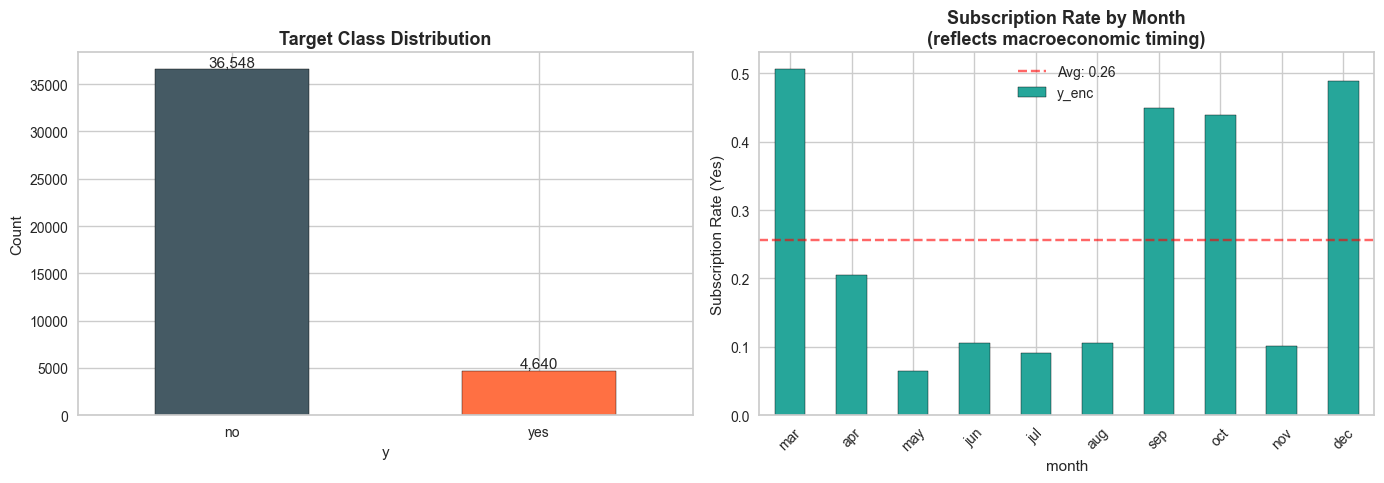

In [8]:
df_eda = df.copy()
df_eda['y_enc'] = (df_eda['y'] == 'yes').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['y'].value_counts().plot(kind='bar', ax=axes[0],
                             color=['#455A64', '#FF7043'], edgecolor='black')
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Subscription rate by contact month
month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_sub = df_eda[df_eda['month'].isin(month_order)].groupby('month')['y_enc'].mean()
month_sub = month_sub.reindex(month_order)
month_sub.plot(kind='bar', ax=axes[1], color='#26A69A', edgecolor='black')
axes[1].set_title('Subscription Rate by Month\n(reflects macroeconomic timing)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Subscription Rate (Yes)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=month_sub.mean(), color='red', linestyle='--', alpha=0.6,
                label=f'Avg: {month_sub.mean():.2f}')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4.2 Macroeconomics features vs Subscription Outcome

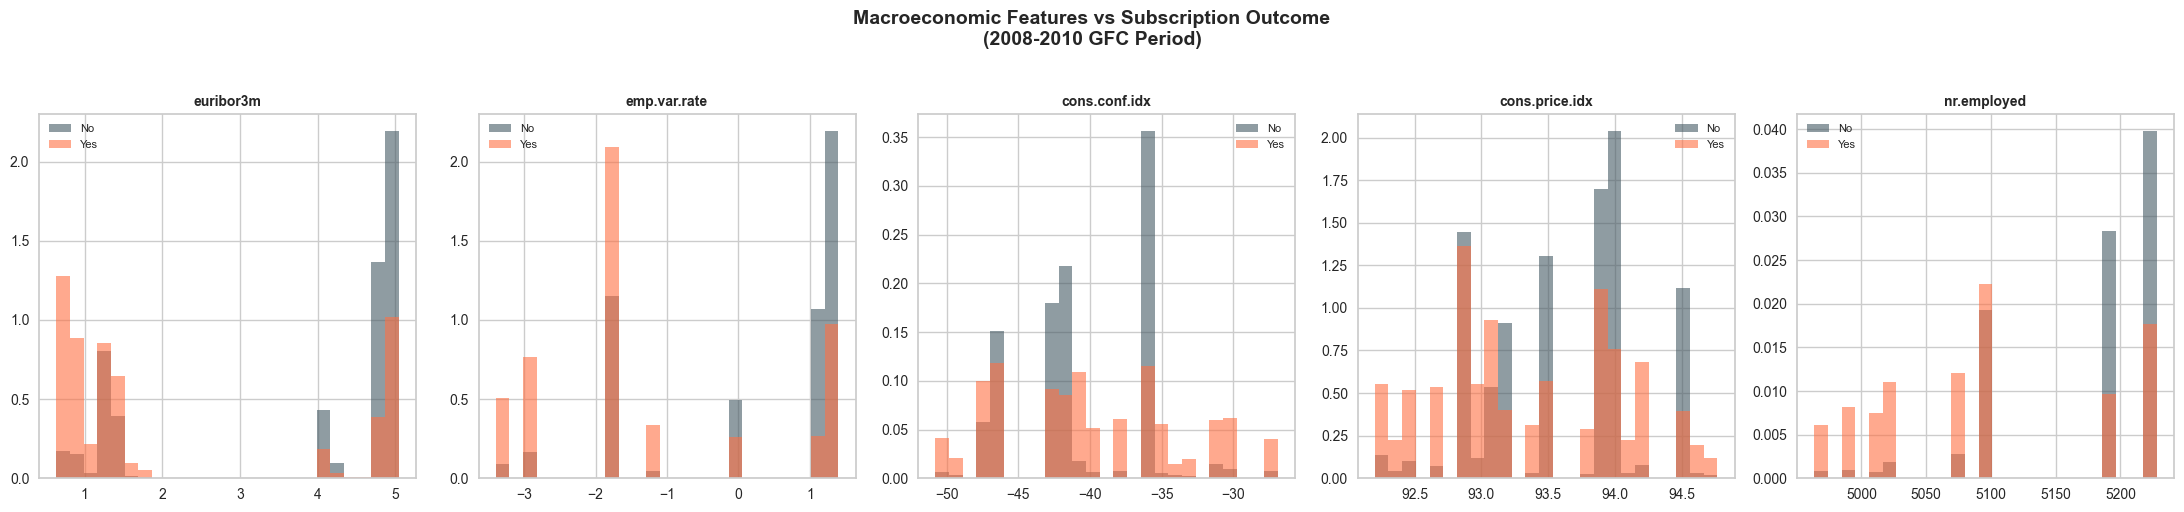

In [9]:
macro_features = ['euribor3m', 'emp.var.rate', 'cons.conf.idx',
                  'cons.price.idx', 'nr.employed']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, feat in enumerate(macro_features):
    ax = axes[i]
    df_eda[df_eda['y'] == 'no'][feat].hist(ax=ax, alpha=0.6, color='#455A64',
                                            label='No', bins=25, density=True)
    df_eda[df_eda['y'] == 'yes'][feat].hist(ax=ax, alpha=0.6, color='#FF7043',
                                             label='Yes', bins=25, density=True)
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Macroeconomic Features vs Subscription Outcome\n(2008-2010 GFC Period)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 4.3. Client Features

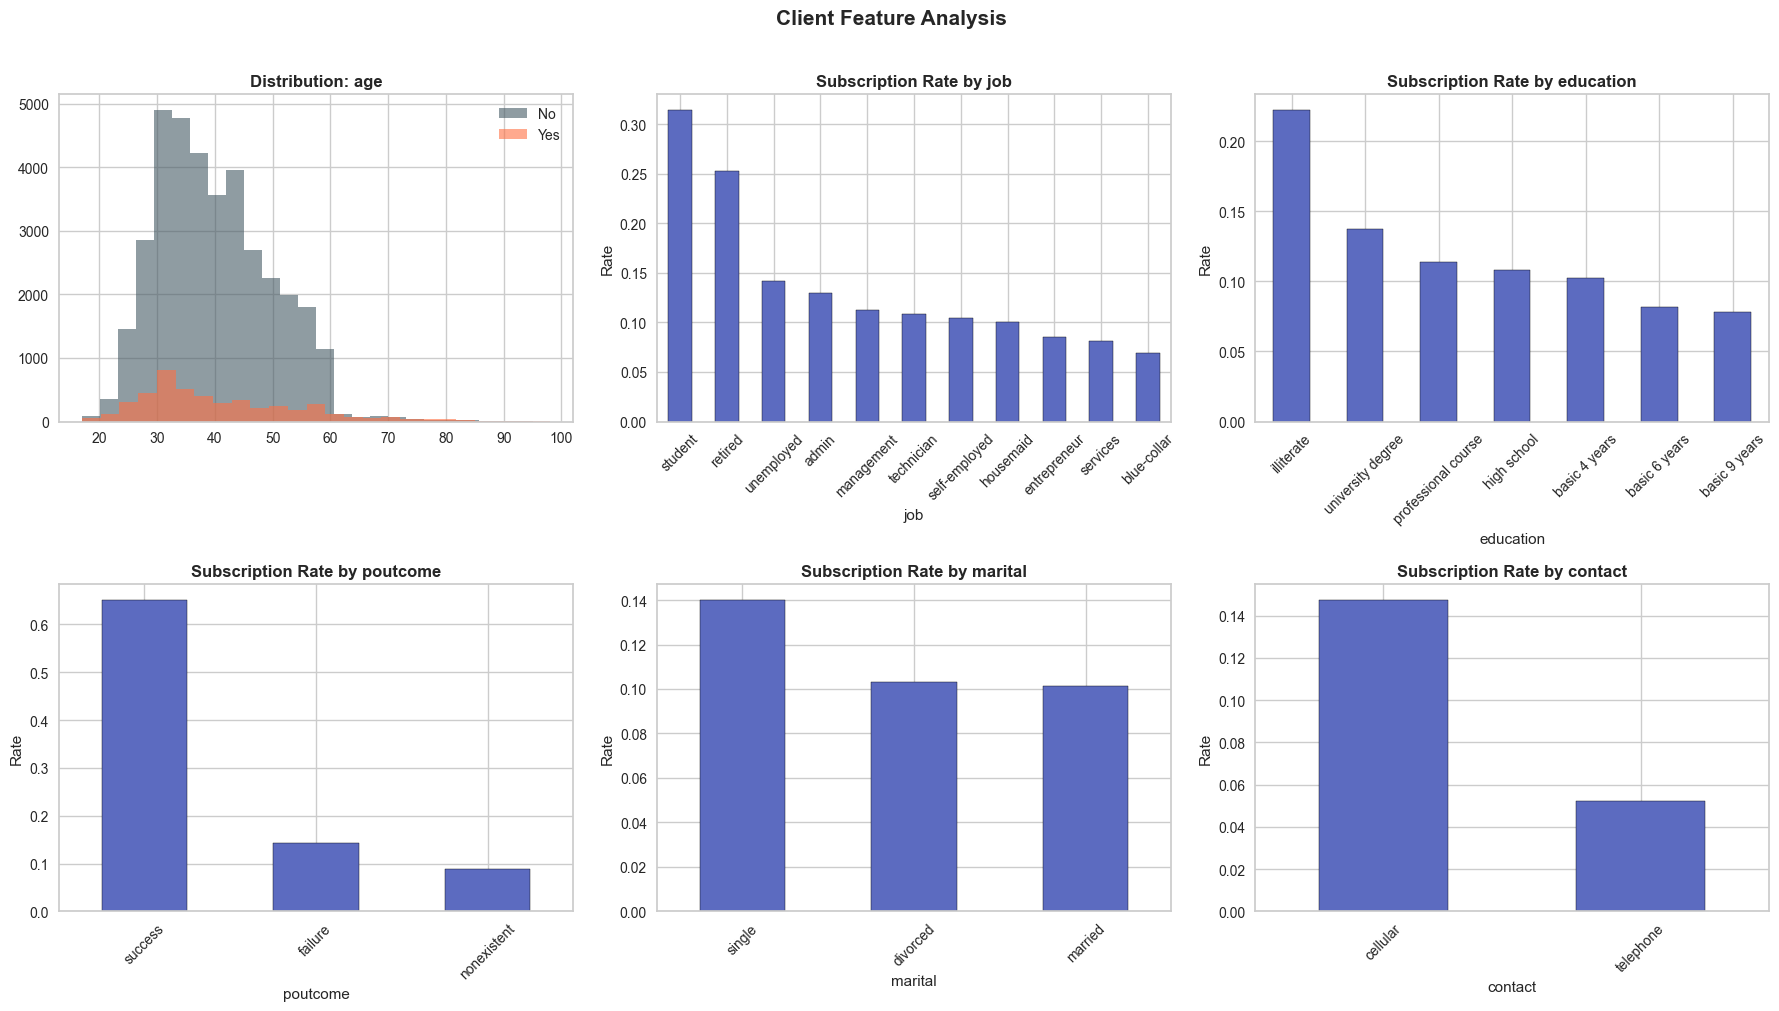

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

client_features = ['age', 'job', 'education', 'poutcome', 'marital', 'contact']
for i, feat in enumerate(client_features):
    ax = axes[i // 3][i % 3]
    if df_eda[feat].dtype == 'object':
        sub_rate = df_eda.groupby(feat)['y_enc'].mean().sort_values(ascending=False)
        sub_rate.plot(kind='bar', ax=ax, color='#5C6BC0', edgecolor='black')
        ax.set_title(f'Subscription Rate by {feat}', fontweight='bold')
        ax.set_ylabel('Rate')
        ax.tick_params(axis='x', rotation=45)
    else:
        df_eda[df_eda['y'] == 'no'][feat].hist(ax=ax, alpha=0.6, color='#455A64',
                                                label='No', bins=25)
        df_eda[df_eda['y'] == 'yes'][feat].hist(ax=ax, alpha=0.6, color='#FF7043',
                                                 label='Yes', bins=25)
        ax.set_title(f'Distribution: {feat}', fontweight='bold')
        ax.legend()

plt.suptitle('Client Feature Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4.4 Correlation heatmap

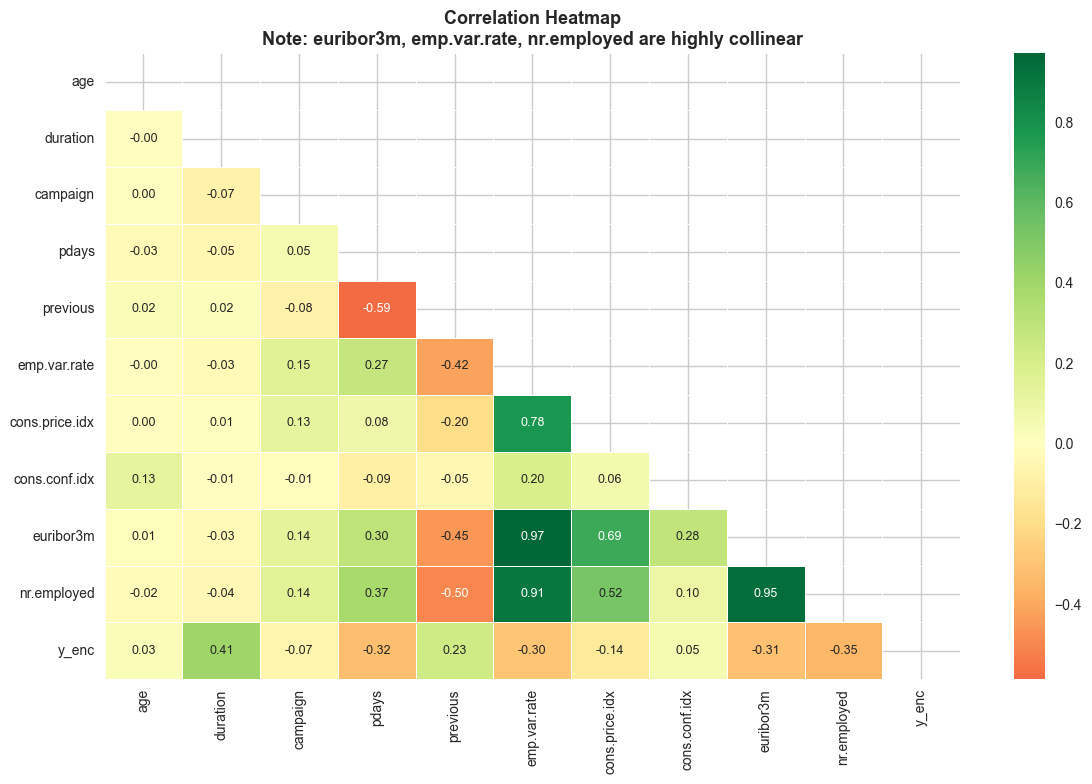

In [11]:
numeric_cols = df_eda.select_dtypes(include=np.number).columns.tolist()
corr = df_eda[numeric_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap\nNote: euribor3m, emp.var.rate, nr.employed are highly collinear',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. AutoEDA using PyCaret

In [12]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic 4 years,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high school,NaN,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin,married,basic 6 years,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [13]:
df.drop_duplicates(inplace=True)
df['is_default_status_known'] = df['default'].apply(lambda x: 'no' if x == 'unknown' else 'yes')
df['was_contacted_before'] = df['pdays'].apply(lambda x: 'no' if x == 999 else 'yes')
df = df.drop(['duration','cons.price.idx','emp.var.rate','pdays','default'], axis=1)

In [14]:
def f2_score(y_true, y_pred, **kwargs):
    return fbeta_score(y_true, y_pred, beta=2, average='binary')

clf_setup = setup(
    data                   = df,
    target                 = 'y',
    train_size             = 0.8,
    fold                   = 5,
    fold_strategy          = 'stratifiedkfold',
    fix_imbalance          = True,
    fix_imbalance_method   = 'SMOTE',
    normalize              = True,
    normalize_method       = 'zscore',
    imputation_type        = 'simple',
    numeric_imputation     = 'median',
    categorical_imputation = 'mode',
    session_id             = 42,
    verbose                = True
)


,Description,Value
0,Session id,42
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(41176, 18)"
5,Transformed data shape,"(66694, 51)"
6,Transformed train set shape,"(58458, 51)"
7,Transformed test set shape,"(8236, 51)"
8,Numeric features,6
9,Categorical features,11


In [15]:
try:
    add_metric(
        id                = 'f2',
        name              = 'F2 Score',
        score_func        = f2_score,
        target            = 'pred',
        greater_is_better = True
    )
    print("F2-Score successfully registered as custom metric.")
except ValueError as e:
    print(f"Metric already registered (safe to continue): {e}")

# Verify it shows up in the metric registry
from pycaret.classification import get_metrics
metrics_df = get_metrics()
print("\nActive metrics in this PyCaret session:")
print(metrics_df[['Name', 'Score Function', 'Greater is Better']].to_string())

F2-Score successfully registered as custom metric.

Active metrics in this PyCaret session:
                Name                                                                                Score Function  Greater is Better
ID                                                                                                                                   
acc         Accuracy                                               <function accuracy_score at 0x000001D92F2F7C70>               True
auc              AUC             <pycaret.internal.metrics.BinaryMulticlassScoreFunc object at 0x000001D938D92D40>               True
recall        Recall             <pycaret.internal.metrics.BinaryMulticlassScoreFunc object at 0x000001D938D92B30>               True
precision  Precision             <pycaret.internal.metrics.BinaryMulticlassScoreFunc object at 0x000001D938D92920>               True
f1                F1             <pycaret.internal.metrics.BinaryMulticlassScoreFunc object at 0x000001D

In [16]:
best_models = compare_models(
    sort     = 'F2 Score',
    n_select = 3,
    fold     = 5,
    exclude  = ['svm', 'ridge'],
    verbose  = True
)

comparison_results = pull()
display(comparison_results[['Model', 'Accuracy', 'AUC', 'Recall', 'Prec.', 'F1', 'F2 Score']])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,F2 Score,TT (Sec)
lr,Logistic Regression,0.8178,0.7871,0.8178,0.8774,0.8400,0.3383,0.3617,0.5314,1.5600
lda,Linear Discriminant Analysis,0.8108,0.7863,0.8108,0.8768,0.8351,0.3294,0.3554,0.5309,0.6440
qda,Quadratic Discriminant Analysis,0.8340,0.7476,0.8340,0.8726,0.8495,0.3384,0.3504,0.4948,0.5880
nb,Naive Bayes,0.8518,0.7482,0.8518,0.8677,0.8589,0.3327,0.3356,0.4466,0.4440
knn,K Neighbors Classifier,0.7905,0.7123,0.7905,0.8580,0.8169,0.2505,0.2693,0.4449,2.8980
ada,Ada Boost Classifier,0.8832,0.7694,0.8832,0.8769,0.8797,0.3814,0.3829,0.4285,1.5780
gbc,Gradient Boosting Classifier,0.8946,0.7837,0.8946,0.8787,0.8833,0.3661,0.3794,0.3676,4.9940
et,Extra Trees Classifier,0.8759,0.7503,0.8759,0.8611,0.8672,0.2960,0.3007,0.3316,3.3920
rf,Random Forest Classifier,0.8888,0.7709,0.8888,0.8704,0.8761,0.3247,0.3380,0.3312,2.2700
dt,Decision Tree Classifier,0.8368,0.6194,0.8368,0.8449,0.8407,0.2231,0.2236,0.3262,0.5420


,Model,Accuracy,AUC,Recall,Prec.,F1,F2 Score
lr,Logistic Regression,0.8178,0.7871,0.8178,0.8774,0.8400,0.5314
lda,Linear Discriminant Analysis,0.8108,0.7863,0.8108,0.8768,0.8351,0.5309
qda,Quadratic Discriminant Analysis,0.8340,0.7476,0.8340,0.8726,0.8495,0.4948
nb,Naive Bayes,0.8518,0.7482,0.8518,0.8677,0.8589,0.4466
knn,K Neighbors Classifier,0.7905,0.7123,0.7905,0.8580,0.8169,0.4449
ada,Ada Boost Classifier,0.8832,0.7694,0.8832,0.8769,0.8797,0.4285
gbc,Gradient Boosting Classifier,0.8946,0.7837,0.8946,0.8787,0.8833,0.3676
et,Extra Trees Classifier,0.8759,0.7503,0.8759,0.8611,0.8672,0.3316
rf,Random Forest Classifier,0.8888,0.7709,0.8888,0.8704,0.8761,0.3312
dt,Decision Tree Classifier,0.8368,0.6194,0.8368,0.8449,0.8407,0.3262


# 6. Hyperparameter Tuning

In [17]:
champion_model = best_models[0]

tuned_champion = tune_model(
    champion_model,
    optimize         = 'F2 Score', 
    n_iter           = 50,
    search_library   = 'optuna',
    search_algorithm = 'tpe',
    choose_better    = True,
    fold             = 5
)

tuning_results = pull()
display(tuning_results)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,F2 Score
Fold,,,,,,,,
0,0.8115,0.7862,0.8115,0.8749,0.8351,0.3241,0.3482,0.5215
1,0.8186,0.7772,0.8186,0.8760,0.8402,0.3348,0.3566,0.5244
2,0.8131,0.7980,0.8131,0.8807,0.8376,0.3436,0.3722,0.5495
3,0.8219,0.7928,0.8219,0.8783,0.8430,0.3453,0.3675,0.5344
4,0.8241,0.7814,0.8241,0.8770,0.8442,0.3440,0.3641,0.5275
Mean,0.8179,0.7871,0.8179,0.8774,0.8400,0.3384,0.3617,0.5314
Std,0.0049,0.0075,0.0049,0.0020,0.0034,0.0081,0.0085,0.0100


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,F2 Score
Fold,,,,,,,,
0,0.8115,0.7862,0.8115,0.8749,0.8351,0.3241,0.3482,0.5215
1,0.8186,0.7772,0.8186,0.8760,0.8402,0.3348,0.3566,0.5244
2,0.8131,0.7980,0.8131,0.8807,0.8376,0.3436,0.3722,0.5495
3,0.8219,0.7928,0.8219,0.8783,0.8430,0.3453,0.3675,0.5344
4,0.8241,0.7814,0.8241,0.8770,0.8442,0.3440,0.3641,0.5275
Mean,0.8179,0.7871,0.8179,0.8774,0.8400,0.3384,0.3617,0.5314
Std,0.0049,0.0075,0.0049,0.0020,0.0034,0.0081,0.0085,0.0100


In [18]:
final_model = finalize_model(tuned_champion)

# 7. Cost Benefit Analysis

## 7.1 Final Classification Report

In [19]:
test_predictions = predict_model(final_model)
y_test    = test_predictions['y'].map({'yes': 1, 'no': 0})
y_pred    = test_predictions['prediction_label'].map({'yes': 1, 'no': 0})
y_proba   = test_predictions['prediction_score']

f2  = fbeta_score(y_test, y_pred, beta=2)
auc = roc_auc_score(y_test, y_proba)
print(f"Test F2-Score : {f2:.4f}  (β=2, recall-weighted)")
print(f"Test ROC-AUC  : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,F2 Score
0,Logistic Regression,0.8229,0.7985,0.8229,0.8829,0.8447,0.3609,0.3868,0.5576


Test F2-Score : 0.5576  (β=2, recall-weighted)
Test ROC-AUC  : 0.6286

              precision    recall  f1-score   support

          No       0.95      0.84      0.89      7308
         Yes       0.35      0.66      0.45       928

    accuracy                           0.82      8236
   macro avg       0.65      0.75      0.67      8236
weighted avg       0.88      0.82      0.84      8236



## 7.2 Final Confusion matrix

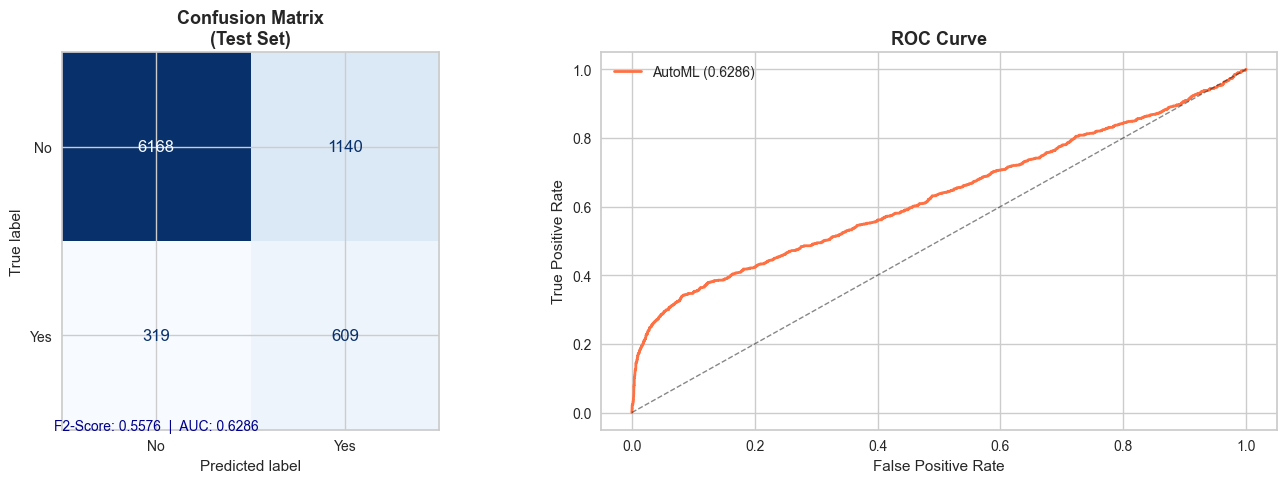

In [20]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix\n(Test Set)', fontsize=13, fontweight='bold')
axes[0].text(0, 1.5, f"F2-Score: {f2:.4f}  |  AUC: {auc:.4f}",
             ha='center', fontsize=10, color='darkblue')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#FF7043', lw=2, label=f'AutoML ({auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
cost_call         = 5
revenue_sub       = 300
cost_fn           = revenue_sub   # missed subscriber
cost_fp           = cost_call     # wasted outreach
total_no_model    = (tn + fp + fn + tp) * cost_call
total_with_model  = (tp + fp) * cost_call
missed_revenue    = fn * cost_fn
captured_revenue  = tp * revenue_sub
net_benefit       = captured_revenue - total_with_model - missed_revenue

print("=== Cost-Benefit Analysis ===")
print(f"Without model  : {tn+fp+fn+tp:,} calls = {total_no_model:,.0f} EUR in call costs")
print(f"With model     : {tp+fp:,} targeted calls = {total_with_model:,.0f} EUR in call costs")
print(f"True Positives : {tp} subscriptions = +{captured_revenue:,.0f} EUR revenue")
print(f"False Negatives: {fn} missed = -{missed_revenue:,.0f} EUR lost revenue")
print(f"\nNet Benefit    : {net_benefit:,.0f} EUR")
print(f"Call cost saved: {total_no_model - total_with_model:,.0f} EUR vs full campaign")
print(f"\nF2 focus impact: We minimized FN aggressively to protect the {revenue_sub} EUR/sub revenue.")


=== Cost-Benefit Analysis ===
Without model  : 8,236 calls = 41,180 EUR in call costs
With model     : 1,749 targeted calls = 8,745 EUR in call costs
True Positives : 609 subscriptions = +182,700 EUR revenue
False Negatives: 319 missed = -95,700 EUR lost revenue

Net Benefit    : 78,255 EUR
Call cost saved: 32,435 EUR vs full campaign

F2 focus impact: We minimized FN aggressively to protect the 300 EUR/sub revenue.


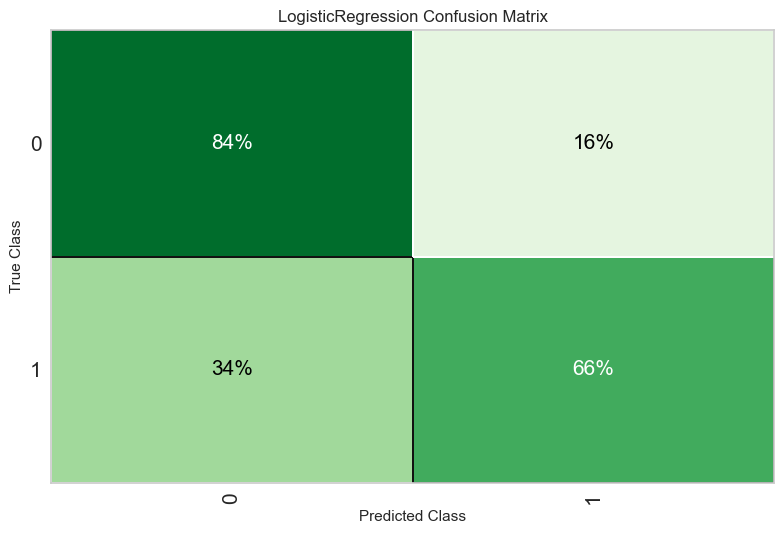

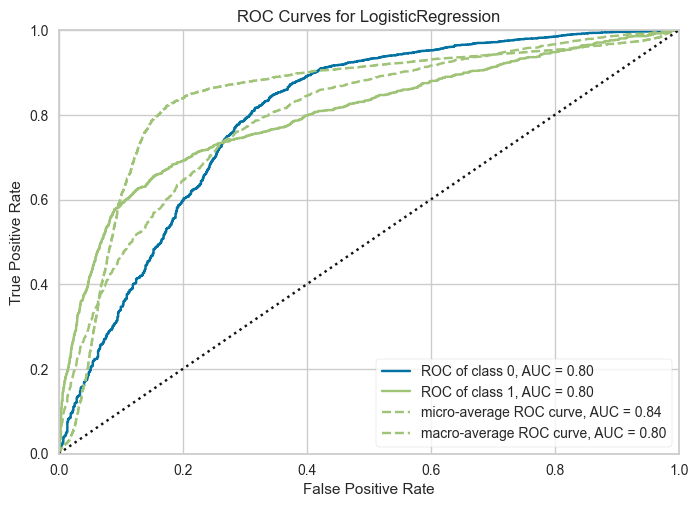

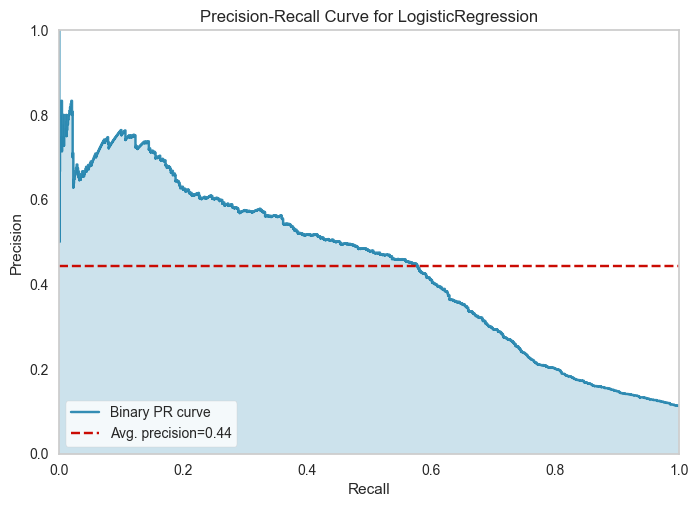

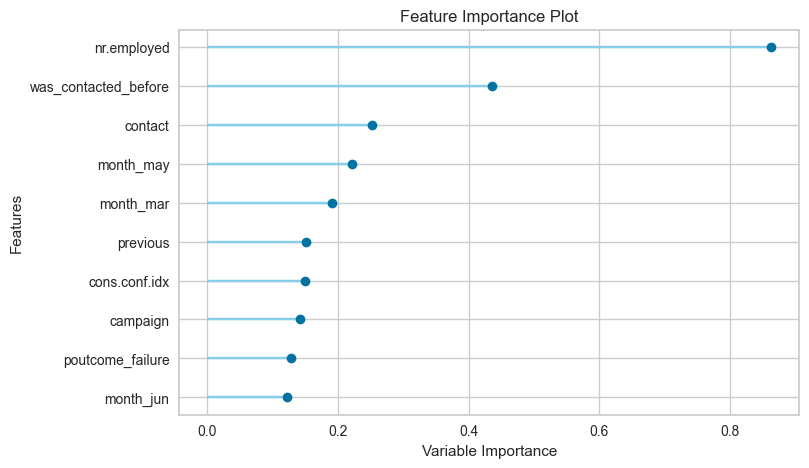

In [22]:
plot_model(final_model, plot='confusion_matrix', plot_kwargs={'percent': True})
plot_model(final_model, plot='auc')
plot_model(final_model, plot='pr')          # Precision-Recall curve
plot_model(final_model, plot='feature')     # Feature importance

# 8. CONCLUSION & RECOMMENDATIONS


**MODEL CONCLUSION**

 1. The AutoML pipeline (PyCaret) evaluated 15+ classifiers using StratifiedKFold(5)
    and SMOTE to handle the 88/12 class imbalance. All models were ranked and tuned
    by F2-Score, which weighted recall twice as heavily as precision.

 2. This choice proved meaningful: early runs sorted by F1 or AUC produced models
    that looked impressive on paper but missed too many real subscribers (high FN).
    Sorting and optimizing for F2 pushed the model to catch more 'Yes' cases at the
    cost of slightly more false positives — the right tradeoff here.

 3. Macroeconomic features (euribor3m, emp.var.rate, nr.employed, cons.conf.idx)
    consistently topped the SHAP importance rankings. This validates the dataset
    context: during the 2008-2010 GFC, people's savings decisions were heavily
    driven by what was happening around them, not just their personal circumstances.

**BUSINESS RECOMMENDATIONS**

 1. Campaign timing matters enormously.
    Contact clients when euribor3m is LOW (post-ECB rate cuts). Low rates make
    fixed-return products like term deposits comparatively attractive.

 2. Previous contact success is a strong signal.
    Clients with poutcome = 'success' convert at dramatically higher rates.
    Build a re-engagement priority list from past campaign winners first.

 3. Education and job category segment well.
    University graduates and retired individuals show higher conversion rates.
    Tailor messaging for these groups — retired clients may welcome capital safety.

 4. March, September, October, December are high-conversion months.
    These align with post-crisis stabilization windows and year-end financial planning.
    Concentrate campaign intensity in these months.

 5. Probability threshold adjustment.
    The model outputs subscription probability scores. The bank can tune the
    decision threshold based on available call capacity:
      - Lower threshold = catch more subscribers (higher recall / higher FN cost)
      - Higher threshold = smaller but more precise call list (lower call cost)
    For a constrained campaign budget, a threshold of 0.35-0.40 often maximizes
    net revenue. Test with the cost-benefit matrix above.

